# Agentic Signal versus Background Classification for Exotic Higgs Decays

This tutorial uses a collider-physics binary classification problem. The goal is to distinguish an exotic-Higgs signal from Standard Model heavy-flavour background.

| Signal process | Background process |
|---|---|
| $pp \to H$ | $pp \to \mathrm{QCD\ heavy\ flavour}$ |
| $H \to aa$ | examples: $b\bar{b}j$, $b\bar{b}jj$, $b\bar{b}b\bar{b}$ |
| $a \to b\bar{b}$ and $a \to b\bar{b}$ | multijet final states with heavy-flavour jets |
| final state: $b\bar{b}b\bar{b}$ | final state: jets that can mimic four-b signal events |

| Signal Feynman-diagram sketch | Background Feynman-diagram sketch |
|---|---|
| $pp \to H \to aa \to (b\bar{b})(b\bar{b})$ | $pp \to \mathrm{QCD} \to b\bar{b}+\mathrm{jets}$ |

The machine-learning task is binary classification:

- `label = 1`: exotic-Higgs signal.
- `label = 0`: QCD heavy-flavour background.

The physics objective is to identify events that are more signal-like than background-like, then check whether applying a classifier threshold improves a simple counting sensitivity. The workflow uses `Avencast/EveNet-ExoticHiggs-H2a4b`, associated with arXiv:2601.17126 and released with an MIT license. Only a small number of Parquet files are downloaded; the full dataset is not required.


## Section 1 - Setup Data

The helper `load_physics_pipeline` handles the low-level parsing of the EveNet Parquet file and returns a compact pandas dataframe called `selected_events`. The dataframe is arranged so the physics objects have consistent names:

- `label`: signal/background class label.
- `jet1`, `jet2`, `jet3`, `jet4`: the four leading jets ordered by transverse momentum.
- `pt`: transverse momentum, the momentum perpendicular to the proton beam.
- `eta`: pseudorapidity, a coordinate related to the jet direction along the beam axis.
- `phi`: azimuthal angle around the beam axis.
- `mass`: reconstructed jet mass.
- `btag`: b-tag information used to identify jets likely produced by bottom quarks.

The initial plots below show the cleaned four-jet sample before any agent modifies features or classifiers.

Infrastructure note: helper functions hide low-level file parsing and LLM response validation. Model training code is intentionally visible in the notebook through one `ClassificationAgent` class with a small model library.

Visible helper contracts:

| Helper | Input | Output |
| --- | --- | --- |
| `load_physics_pipeline(...)` | number of files, event cap, random seed | dictionary containing `selected_events`, cut-flow tables, and schema summaries |
| `request_strategy_from_nvidia(...)` | prompt, history, dataset summary, baseline summary, agent catalog | validated strategy dictionary |
| `summarize_planning_round(...)` | round number, plan, classifier agent, best threshold result | compact round summary for the next planning prompt |


In [12]:
%matplotlib inline

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use paths relative to the notebook location so this folder can be copied elsewhere.
notebook_dir = Path.cwd()
if not (notebook_dir / "agentic_lab7").exists() and (notebook_dir / "lab7" / "agentic_lab7").exists():
    notebook_dir = notebook_dir / "lab7"
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from agentic_lab7.api_key import NVIDIA_API_KEY, NVIDIA_MODEL
from agentic_lab7.pipeline_setup import load_physics_pipeline
from agentic_lab7.planning_tools import request_strategy_from_nvidia, summarize_round as summarize_planning_round

RANDOM_STATE = 123
MAX_EVENTS = 200_000
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (7, 5)


,raw_events_loaded,selected_events,columns
0,200000,75126,21


,label,jet1_pt,jet1_eta,jet1_phi,jet1_mass,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_mass,...,jet3_pt,jet3_eta,jet3_phi,jet3_mass,jet3_btag,jet4_pt,jet4_eta,jet4_phi,jet4_mass,jet4_btag
0,1.0,93.664531,-0.087359,-2.475345,9.789335,1.0,80.338509,1.576945,0.333819,0.000000,...,34.622795,0.511399,-2.549871,5.108600,1.0,32.414450,0.552133,2.214729,2.505994,1.0
1,1.0,61.916652,0.902399,0.266193,0.000000,0.0,47.088154,0.198319,2.316577,8.675580,...,46.221401,0.692270,-2.392012,1.113719,1.0,37.838821,0.947641,2.469884,0.000000,1.0
2,1.0,67.839815,-0.506841,-1.267455,8.586977,1.0,62.954586,-2.280551,-0.061890,0.000000,...,50.028944,-2.729800,1.251373,0.000000,1.0,44.099123,-3.184988,-2.491740,0.000000,1.0
3,0.0,52.155311,0.724185,1.833906,1.579675,1.0,46.139782,-2.184562,-1.162588,0.000000,...,39.789092,-0.756486,0.927674,2.875871,1.0,38.916300,-0.945284,-1.449909,6.906621,0.0
4,0.0,73.618286,0.643026,1.586173,5.096674,1.0,70.661523,-0.555229,-2.147839,10.997287,...,67.678974,0.281106,-2.774277,9.377133,1.0,60.258595,-1.421532,0.500439,0.000000,1.0


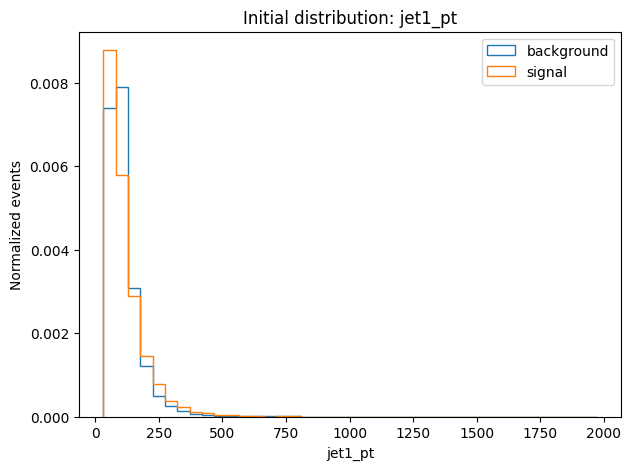

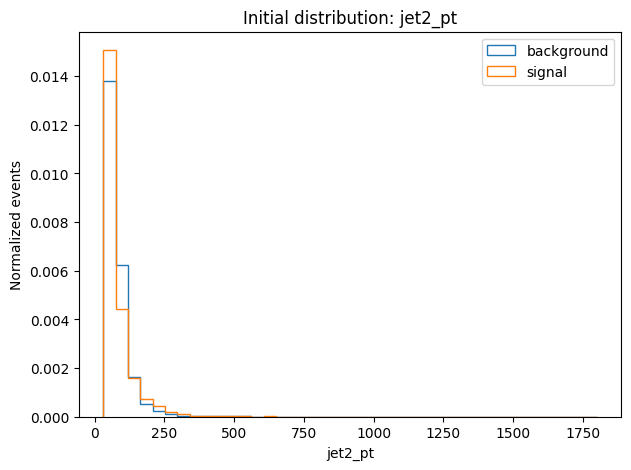

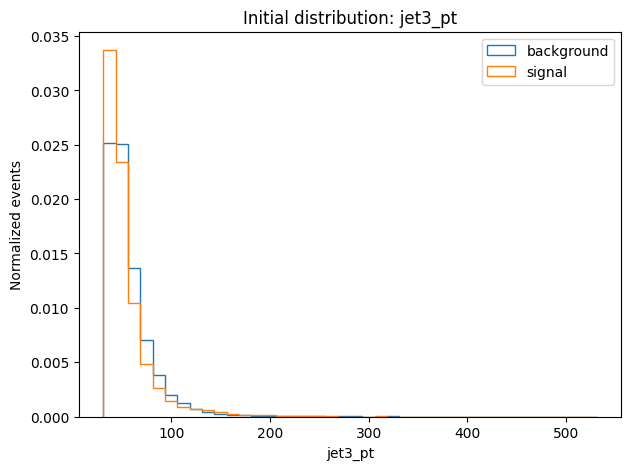

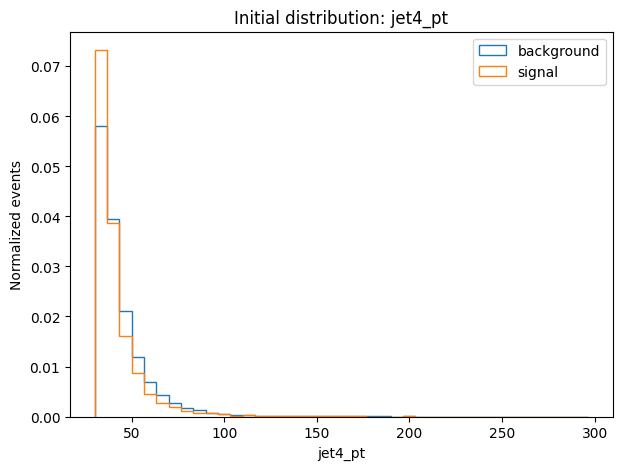

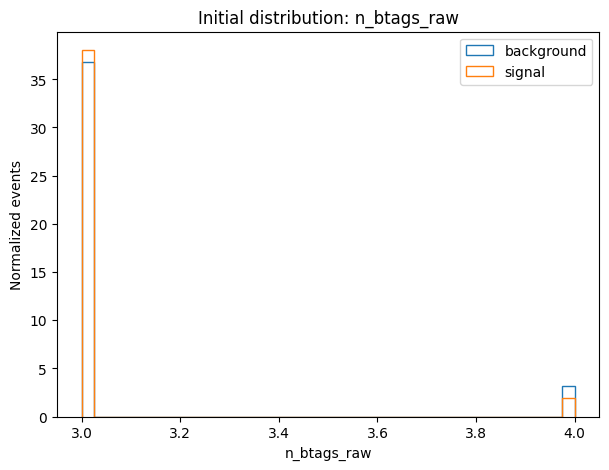

In [5]:
N_FILES_TO_USE = 24
pipeline = load_physics_pipeline(
    n_files_to_use=N_FILES_TO_USE,
    max_events=MAX_EVENTS,
    random_state=RANDOM_STATE,
)

selected_events = pipeline["selected_events"]

display(pd.DataFrame({
    "raw_events_loaded": [len(pipeline["data"])],
    "selected_events": [len(selected_events)],
    "columns": [selected_events.shape[1]],
}))
display(selected_events.head())

selected_events["n_btags_raw"] = selected_events[[f"jet{i}_btag" for i in range(1, 5)]].sum(axis=1)
plot_columns = ["jet1_pt", "jet2_pt", "jet3_pt", "jet4_pt", "n_btags_raw"]
for column in plot_columns:
    values = selected_events[column].dropna().to_numpy()
    bins = np.histogram_bin_edges(values, bins=40)
    plt.figure()
    for label, name in [(0, "background"), (1, "signal")]:
        class_values = selected_events.loc[selected_events["label"] == label, column].dropna().to_numpy()
        plt.hist(class_values, bins=bins, histtype="step", density=True, label=name)
    plt.xlabel(column)
    plt.ylabel("Normalized events")
    plt.title(f"Initial distribution: {column}")
    plt.legend()
    plt.show()


## Section 2 - Feature Agent Template Class

The feature agent transforms the cleaned event dataframe into an ML-ready feature matrix. It keeps the direct four-jet measurements and adds derived physics variables that summarize the event topology.

Direct per-jet features:

- `jetN_pt`: transverse momentum of jet `N`.
- `jetN_eta`: pseudorapidity of jet `N`.
- `jetN_phi`: azimuthal angle of jet `N`.
- `jetN_mass`: reconstructed mass of jet `N`.
- `jetN_btag`: b-tag value for jet `N`; the code counts a jet as tagged when this value is at least 0.5.

Derived event features:

- `ht`: scalar sum of the four jet transverse momenta, $p_{T,1}+p_{T,2}+p_{T,3}+p_{T,4}$.
- `m_4j`: invariant mass of the four-jet system.
- `m_jj_12`, ..., `m_jj_34`: invariant masses of all six jet pairs.
- `deltaR_jj_12`, ..., `deltaR_jj_34`: angular separations between jet pairs, using $\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2}$ with $\Delta\phi$ wrapped into $[-\pi, \pi]$.
- `min_deltaR_jj`: smallest pairwise jet separation in the event.
- `mean_deltaR_jj`: average pairwise jet separation in the event.
- `n_btags`: number of the four leading jets passing the b-tag threshold.

These variables encode the signal hypothesis. In $H 	o aa 	o bar{b}bar{b}$, the final state contains four b quarks, often organized into two pairs from the intermediate particles `a`. QCD background can also contain b jets, but its pair masses, angular structure, total activity, and b-tag multiplicity do not have to follow the same pattern.

In [6]:
# Fill in the feature construction inside FeatureAgent.
class FeatureAgent:
    def __init__(self, name="four_jet_feature_agent"):
        self.name = name
        self.X = None
        self.y = None

    @staticmethod
    def delta_phi(phi1, phi2):
        # YOUR CODE HERE
        dphi = phi2 - phi1
        return (dphi + np.pi) % (2 * np.pi) - np.pi

    @staticmethod
    def four_vector(df, jet):
        pt = df[f"jet{jet}_pt"].astype(float)
        eta = df[f"jet{jet}_eta"].astype(float)
        phi = df[f"jet{jet}_phi"].astype(float)
        mass = df[f"jet{jet}_mass"].astype(float)

        # YOUR CODE HERE
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        energy = np.sqrt(mass**2 + pt**2 + pz**2)

        return pd.DataFrame({"E": energy, "px": px, "py": py, "pz": pz}, index=df.index)

    @staticmethod
    def invariant_mass(vectors):
        # YOUR CODE HERE
        E  = sum(v["E"]  for v in vectors)
        px = sum(v["px"] for v in vectors)
        py = sum(v["py"] for v in vectors)
        pz = sum(v["pz"] for v in vectors)
        m2 = E**2 - px**2 - py**2 - pz**2
        return np.sqrt(np.maximum(m2, 0))

    def delta_r(self, df, i, j):
        # YOUR CODE HERE
        deta = df[f"jet{i}_eta"].astype(float) - df[f"jet{j}_eta"].astype(float)
        dphi = self.delta_phi(df[f"jet{i}_phi"].astype(float), df[f"jet{j}_phi"].astype(float))
        return np.sqrt(deta**2 + dphi**2)

    def features(self, selected_events):
        df = selected_events.copy()
        X = pd.DataFrame(index=df.index)

        # Direct jet features: these are ready to use.
        for jet in range(1, 5):
            for field in ["pt", "eta", "phi", "mass", "btag"]:
                X[f"jet{jet}_{field}"] = df[f"jet{jet}_{field}"].astype(float)

        vectors = {jet: self.four_vector(df, jet) for jet in range(1, 5)}

        X["ht"] = sum(df[f"jet{jet}_pt"].astype(float) for jet in range(1, 5))

        X["m_4j"] = self.invariant_mass([vectors[jet] for jet in range(1, 5)])

        delta_r_values = []
        for i in range(1, 5):
            for j in range(i + 1, 5):
                X[f"m_jj_{i}{j}"] = self.invariant_mass([vectors[i], vectors[j]])

                X[f"deltaR_jj_{i}{j}"] = self.delta_r(df, i, j)
                delta_r_values.append(X[f"deltaR_jj_{i}{j}"])

        delta_r_table = pd.concat(delta_r_values, axis=1)

        X["min_deltaR_jj"] = delta_r_table.min(axis=1)

        X["mean_deltaR_jj"] = delta_r_table.mean(axis=1)

        X["n_btags"] = sum(
            (df[f"jet{jet}_btag"].astype(float) >= 0.5).astype(float) for jet in range(1, 5)
        )

        y = df["label"].astype(int)
        assert np.isfinite(X.to_numpy()).all(), "Feature matrix contains NaN or infinite values. Finish the feature TODOs."
        self.X = X
        self.y = y
        return X, y

    def describe(self):
        n_events = len(self.X) if self.X is not None else 0
        n_features = self.X.shape[1] if self.X is not None else 0
        return f"FeatureAgent `{self.name}` built {n_features} ML features for {n_events:,} selected events."

feature_agent = FeatureAgent()
X, y = feature_agent.features(selected_events)
print(feature_agent.describe())
display(X.head())
display(y.value_counts().sort_index().rename("events"))

FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.


,jet1_pt,jet1_eta,jet1_phi,jet1_mass,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_mass,jet2_btag,...,deltaR_jj_14,m_jj_23,deltaR_jj_23,m_jj_24,deltaR_jj_24,m_jj_34,deltaR_jj_34,min_deltaR_jj,mean_deltaR_jj,n_btags
0,93.664531,-0.087359,-2.475345,9.789335,1.0,80.338509,1.576945,0.333819,0.000000,0.0,...,1.716670,120.710389,3.074257,99.099525,2.141976,46.830577,1.519132,0.603378,2.053430,3.0
1,61.916652,0.902399,0.266193,0.000000,0.0,47.088154,0.198319,2.316577,8.675580,1.0,...,2.204155,71.265440,1.650255,35.390279,0.764843,55.624029,1.444049,0.764843,1.816284,3.0
2,67.839815,-0.506841,-1.267455,8.586977,1.0,62.954586,-2.280551,-0.061890,0.000000,1.0,...,2.944715,73.083284,1.387979,110.394894,2.592716,92.279513,2.580536,1.387979,2.501674,4.0
3,52.155311,0.724185,1.833906,1.579675,1.0,46.139782,-2.184562,-1.162588,0.000000,1.0,...,3.432688,99.805236,2.531520,59.121267,1.272149,74.137131,2.385067,1.272149,2.588918,3.0
4,73.618286,0.643026,1.586173,5.096674,1.0,70.661523,-0.555229,-2.147839,10.997287,1.0,...,2.332642,75.998871,1.044931,140.471465,2.786370,177.377298,3.456857,1.044931,2.399009,4.0


label
0    64345
1    10781
Name: events, dtype: int64

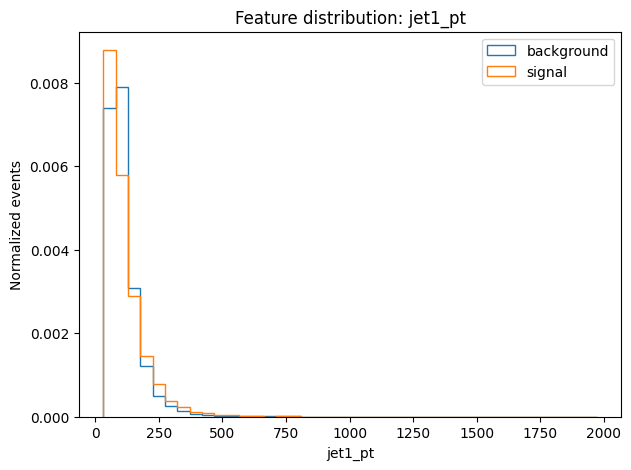

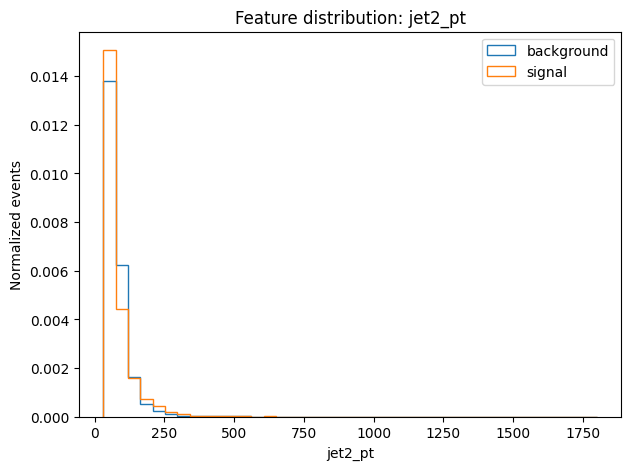

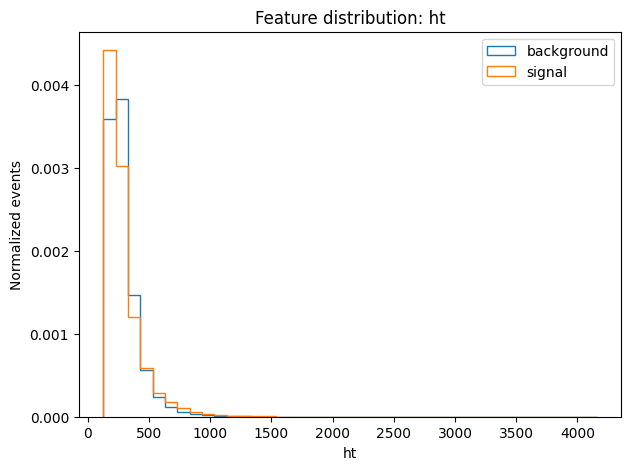

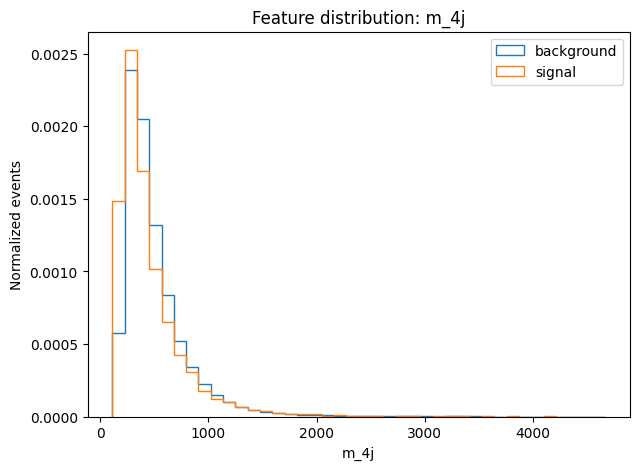

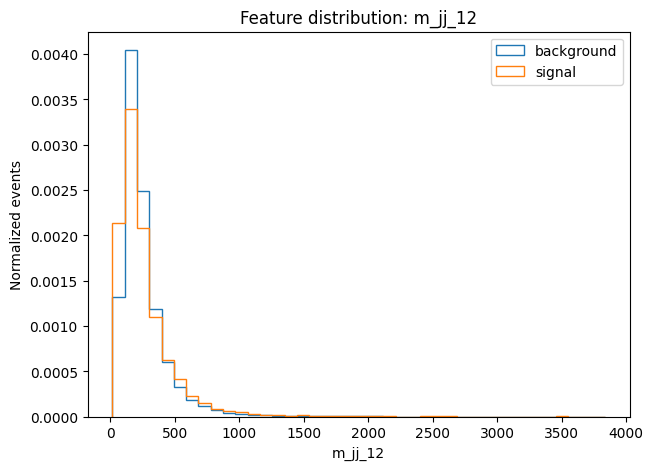

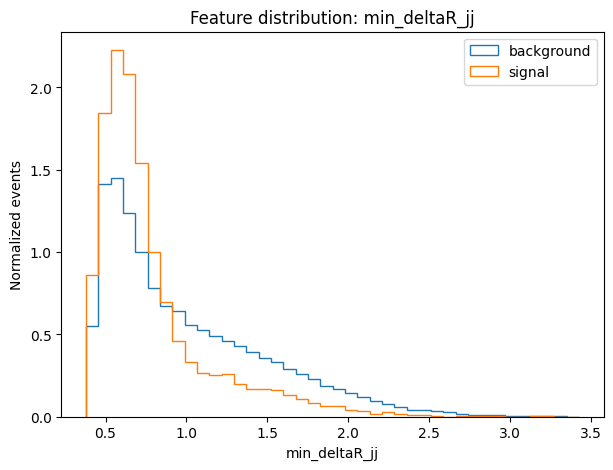

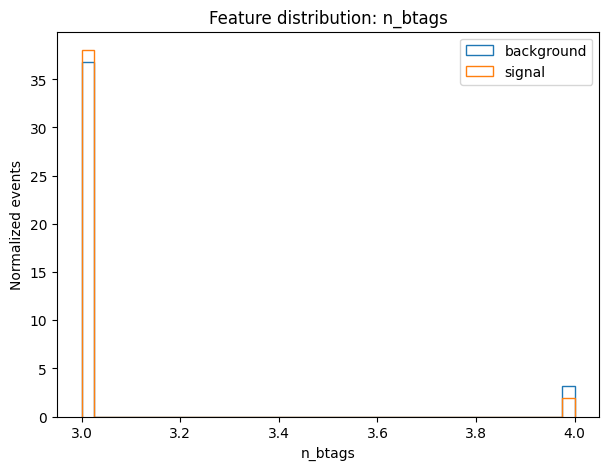

In [7]:
for feature in ["jet1_pt", "jet2_pt", "ht", "m_4j", "m_jj_12", "min_deltaR_jj", "n_btags"]:
    if feature not in X.columns:
        continue
    values = X[feature].dropna().to_numpy()
    bins = np.histogram_bin_edges(values, bins=40)
    plt.figure()
    plt.hist(X.loc[y == 0, feature], bins=bins, histtype="step", density=True, label="background")
    plt.hist(X.loc[y == 1, feature], bins=bins, histtype="step", density=True, label="signal")
    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(f"Feature distribution: {feature}")
    plt.legend()
    plt.show()


## Section 3 - Classification Agent Template Class

`ClassificationAgent` handles shared bookkeeping: feature selection, train/validation/test splitting, optional scaling, metric calculation, and text summaries.

The class handles shared bookkeeping and dispatches to the selected model family:

| Method | Input | Output |
| --- | --- | --- |
| `.train(X, y)` | feature dataframe and label series | fitted classification agent with metrics |
| `.predict(X_new)` | dataframe with the selected feature columns | signal-like score for each row |

Most of the classifier work happens here. Add a new entry to `MODEL_LIBRARY`, then add the matching training block inside `ClassificationAgent.train(...)`. The planning agent can then choose that `model_family`.

In [8]:
def baseline_strategy(feature_columns):
    return {
        "strategy_name": "baseline_random_forest",
        "rationale": "Baseline random forest using all engineered four-jet features.",
        "feature_columns": list(feature_columns),
        "model_family": "random_forest",
        "hyperparameters": {"n_estimators": 160, "min_samples_leaf": 2, "max_features": "sqrt"},
    }


class ClassificationAgent:
    """Train and score one classifier chosen by a planning strategy.

    Add models in two places:
    1. Add a new entry to MODEL_LIBRARY.
    2. Add a new `elif self.model_family == "..."` block in train().

    predict() already works for scikit-learn classifiers with predict_proba.
    """

    MODEL_LIBRARY = {
        "random_forest": {
            "defaults": {"n_estimators": 160, "min_samples_leaf": 2, "max_depth": None, "max_features": "sqrt"},
            "allowed": {"n_estimators", "min_samples_leaf", "max_depth", "max_features"},
            "use_scaler": False,
        },
        # YOUR CODE HERE: add another model_family entry, for example "logistic_regression" or "mlp".
        "extra_trees": {
            "defaults": {"n_estimators": 160, "min_samples_leaf": 2, "max_depth": None, "max_features": "sqrt"},
            "allowed": {"n_estimators", "min_samples_leaf", "max_depth", "max_features"},
            "use_scaler": False,
        },
        "gradient_boosting": {
            "defaults": {"max_iter": 300, "max_depth": 5, "min_samples_leaf": 20, "learning_rate": 0.05, "l2_regularization": 0.1},
            "allowed": {"max_iter", "max_depth", "min_samples_leaf", "learning_rate", "l2_regularization"},
            "use_scaler": False,
        }
    }

    def __init__(self, strategy=None, random_state=RANDOM_STATE):
        self.strategy = strategy
        self.random_state = random_state
        self.name = (strategy or {}).get("strategy_name", "classification_agent")
        self.model_family = (strategy or {}).get("model_family", "random_forest")
        self.feature_names_ = []
        self.hyperparameters = {}
        self.scaler = None
        self.model = None
        self.metrics = {}
        self.n_trained = 0

    @classmethod
    def catalog(cls):
        return {
            name: {
                "defaults": config["defaults"],
                "allowed": config["allowed"],
                "use_scaler": config["use_scaler"],
            }
            for name, config in cls.MODEL_LIBRARY.items()
        }

    def _config(self):
        if self.model_family not in self.MODEL_LIBRARY:
            raise ValueError(f"Unknown model_family {self.model_family!r}. Choose one of {list(self.MODEL_LIBRARY)}.")
        return self.MODEL_LIBRARY[self.model_family]

    def _clean_hyperparameters(self):
        config = self._config()
        params = config["defaults"].copy()
        for key, value in (self.strategy.get("hyperparameters", {}) or {}).items():
            if key in config["allowed"]:
                params[key] = value
        return params

    def _prepare_data(self, X, y):
        if self.strategy is None:
            self.strategy = baseline_strategy(X.columns)
        self.name = self.strategy.get("strategy_name", "classification_agent")
        self.model_family = self.strategy.get("model_family", "random_forest")
        requested = self.strategy.get("feature_columns", [])
        self.feature_names_ = [col for col in requested if col in X.columns and pd.api.types.is_numeric_dtype(X[col])]
        if not self.feature_names_:
            raise ValueError("Classifier strategy did not select any valid numeric feature columns.")
        self.hyperparameters = self._clean_hyperparameters()

        X_selected = X[self.feature_names_].copy()
        self.X_train, X_temp, self.y_train, y_temp = train_test_split(
            X_selected, y, test_size=0.40, stratify=y, random_state=self.random_state
        )
        self.X_val, self.X_test, self.y_val, self.y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=self.random_state
        )

        if self._config()["use_scaler"]:
            self.scaler = StandardScaler()
            self.X_train_model = self.scaler.fit_transform(self.X_train)
        else:
            self.scaler = None
            self.X_train_model = self.X_train

    def _model_input(self, X):
        X_selected = X[self.feature_names_].copy()
        return self.scaler.transform(X_selected) if self.scaler is not None else X_selected

    def train(self, X, y):
        self._prepare_data(X, y)

        if self.model_family == "random_forest":
            params = self.hyperparameters.copy()
            params["n_estimators"] = int(np.clip(int(params.get("n_estimators", 160)), 50, 300))
            params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf", 2)), 1, 20))
            if params.get("max_depth") is not None:
                params["max_depth"] = int(np.clip(int(params["max_depth"]), 2, 40))
            if params.get("max_features") not in ["sqrt", "log2", None]:
                params["max_features"] = "sqrt"
            self.model = RandomForestClassifier(random_state=self.random_state, n_jobs=-1, **params)
            self.model.fit(self.X_train_model, self.y_train)

        # YOUR CODE HERE: add `elif self.model_family == "your_model_name":` blocks.
        # Each block should set `params`, create `self.model`, and fit it on self.X_train_model.

        elif self.model_family == "extra_trees":
            params = self.hyperparameters.copy()
            params["n_estimators"] = int(np.clip(int(params.get("n_estimators", 160)), 50, 300))
            params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf", 2)), 1, 20))
            if params.get("max_depth") is not None:
                params["max_depth"] = int(np.clip(int(params["max_depth"]), 2, 40))
            if params.get("max_features") not in ["sqrt", "log2", None]:
                params["max_features"] = "sqrt"
            self.model = ExtraTreesClassifier(random_state=self.random_state, n_jobs=-1, **params)
            self.model.fit(self.X_train_model, self.y_train)

        elif self.model_family == "gradient_boosting":
            params = self.hyperparameters.copy()
            params["max_iter"] = int(np.clip(int(params.get("max_iter", 300)), 50, 500))
            params["max_depth"] = int(np.clip(int(params.get("max_depth", 5)), 2, 10))
            params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf", 20)), 1, 100))
            params["learning_rate"] = float(np.clip(float(params.get("learning_rate", 0.05)), 0.001, 0.5))
            params["l2_regularization"] = float(np.clip(float(params.get("l2_regularization", 0.1)), 0.0, 10.0))
            self.model = HistGradientBoostingClassifier(random_state=self.random_state, **params)
            self.model.fit(self.X_train_model, self.y_train)


        else:
            raise ValueError(f"No training code is defined for model_family {self.model_family!r}.")

        self.hyperparameters = params
        self.n_trained += 1
        self.metrics["validation"] = self.evaluate(self.X_val, self.y_val)
        self.metrics["test"] = self.evaluate(self.X_test, self.y_test)
        return self

    def predict(self, X):
        scores = self.model.predict_proba(self._model_input(X))[:, 1]
        return np.clip(np.asarray(scores, dtype=float), 0.0, 1.0)

    def evaluate(self, X, y):
        scores = self.predict(X)
        predictions = (scores >= 0.5).astype(int)
        return {
            "accuracy": accuracy_score(y, predictions),
            "auc": roc_auc_score(y, scores),
            "confusion_matrix": confusion_matrix(y, predictions),
            "classification_report": classification_report(y, predictions, zero_division=0),
            "scores": scores,
        }

    def describe(self):
        val_auc = self.metrics.get("validation", {}).get("auc", np.nan)
        test_auc = self.metrics.get("test", {}).get("auc", np.nan)
        return (
            f"ClassificationAgent `{self.name}` trained `{self.model_family}` using {len(self.feature_names_)} features. "
            f"Validation AUC = {val_auc:.3f}; test AUC = {test_auc:.3f}. "
            f"Hyperparameters: {self.hyperparameters}."
        )


AGENT_CATALOG = ClassificationAgent.catalog()

baseline_classifier = ClassificationAgent(strategy=baseline_strategy(X.columns))
baseline_classifier.train(X, y)
baseline_scores = baseline_classifier.predict(baseline_classifier.X_test)
print(baseline_classifier.describe())

ClassificationAgent `baseline_random_forest` trained `random_forest` using 37 features. Validation AUC = 0.810; test AUC = 0.812. Hyperparameters: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_depth': None, 'max_features': 'sqrt'}.


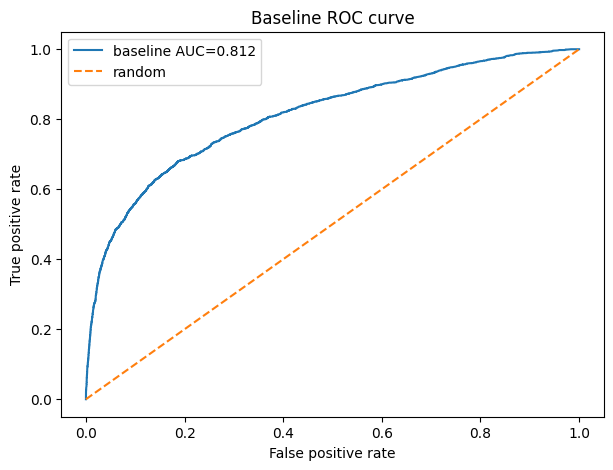

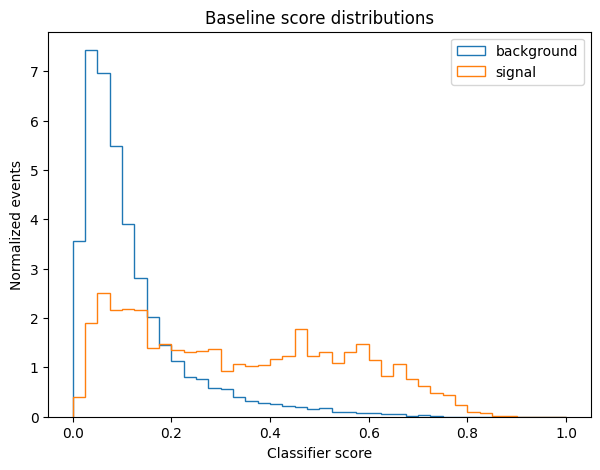

In [9]:
fpr, tpr, _ = roc_curve(baseline_classifier.y_test, baseline_scores)
plt.figure()
plt.plot(fpr, tpr, label=f"baseline AUC={baseline_classifier.metrics['test']['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Baseline ROC curve")
plt.legend()
plt.show()

score_bins = np.linspace(0, 1, 41)
plt.figure()
plt.hist(baseline_scores[baseline_classifier.y_test.to_numpy() == 0], bins=score_bins, histtype="step", density=True, label="background")
plt.hist(baseline_scores[baseline_classifier.y_test.to_numpy() == 1], bins=score_bins, histtype="step", density=True, label="signal")
plt.xlabel("Classifier score")
plt.ylabel("Normalized events")
plt.title("Baseline score distributions")
plt.legend()
plt.show()


## Section 4 - Signal Analysis Agent Template Class

`SignalAnalysisAgent` turns classifier scores into a simple counting analysis.

Fill in the threshold scan yourself. For each threshold, select events with `scores >= threshold`, count selected signal and background events, compute efficiencies, and compute the counting significance $S/\sqrt{B}$.

,threshold,S,B,sig_efficiency,bkg_efficiency,S_over_sqrt_B
0,0.1,1782,5335,0.826531,0.414530,24.397228
1,0.2,1394,2052,0.646568,0.159441,30.773302
2,0.3,1104,994,0.512059,0.077234,35.016754
3,0.4,885,491,0.410482,0.038151,39.939491
4,0.5,594,228,0.275510,0.017716,39.338611
5,0.6,314,85,0.145640,0.006605,34.058082
6,0.7,108,20,0.050093,0.001554,24.149534
7,0.8,11,0,0.005102,0.000000,11.000000
8,0.9,0,0,0.000000,0.000000,0.000000


SignalAnalysisAgent found the best threshold at score >= 0.40, with S/sqrt(B) = 39.94.


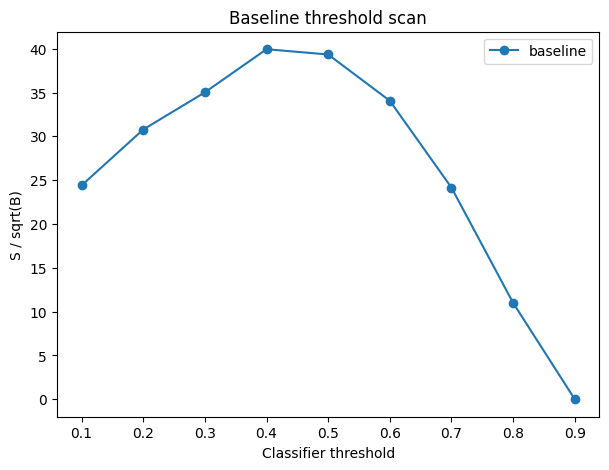

In [10]:
class SignalAnalysisAgent:
    def __init__(self, thresholds=None):
        self.thresholds = thresholds if thresholds is not None else np.arange(0.1, 1.0, 0.1)
        self.scan_table = None
        self.best = None

    def analyze(self, y_true, scores):
        y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
        scores = np.asarray(scores, dtype=float)
        total_signal = max(int((y_true == 1).sum()), 1)
        total_background = max(int((y_true == 0).sum()), 1)
        rows = []

        # YOUR CODE HERE: loop over self.thresholds.
        # For each threshold:
        # - select events with scores >= threshold
        # - count selected signal events S
        # - count selected background events B
        # - compute signal efficiency S / total_signal
        # - compute background efficiency B / total_background
        # - compute counting significance S / sqrt(B)
        # - append one dictionary to rows with the columns used below
        for threshold in self.thresholds:
            mask = scores >= threshold
            S = int((y_true[mask] == 1).sum())
            B = int((y_true[mask] == 0).sum())
            rows.append({
                "threshold": threshold,
                "S": S,
                "B": B,
                "sig_efficiency": S / total_signal,
                "bkg_efficiency": B / total_background,
                "S_over_sqrt_B": S / np.sqrt(max(B, 1)),
            })

        self.scan_table = pd.DataFrame(rows)
        if self.scan_table.empty:
            raise ValueError("Threshold scan is empty. Finish SignalAnalysisAgent.analyze(...).")
        self.best = self.scan_table.sort_values("S_over_sqrt_B", ascending=False, na_position="last").iloc[0]
        return self.scan_table, self.best

    def describe(self):
        return (
            f"SignalAnalysisAgent found the best threshold at score >= {self.best['threshold']:.2f}, "
            f"with S/sqrt(B) = {self.best['S_over_sqrt_B']:.2f}."
        )

signal_agent = SignalAnalysisAgent()
baseline_scan, baseline_best = signal_agent.analyze(baseline_classifier.y_test, baseline_scores)
display(baseline_scan)
print(signal_agent.describe())

plt.figure()
plt.plot(baseline_scan["threshold"], baseline_scan["S_over_sqrt_B"], marker="o", label="baseline")
plt.xlabel("Classifier threshold")
plt.ylabel("S / sqrt(B)")
plt.title("Baseline threshold scan")
plt.legend()
plt.show()

## Section 5 - Planning Agent Template Class

The planning agent reads previous round results and proposes the next classifier strategy. It does not write executable classifier code.

The API call, JSON parsing, and validation are fixed infrastructure. Edit `PLANNING_PROMPT` to direct the strategy: which features to try, which model families to prefer, how much to explore, and how to react to previous results.

Example planning-agent output:

```python
{
    "strategy_name": "extra_trees_mass_and_btag_scan",
    "rationale": "Try a high-capacity tree model using invariant-mass, angular-separation, and b-tag variables that match the four-b signal topology.",
    "feature_columns": [
        "ht",
        "m_4j",
        "m_jj_12",
        "m_jj_13",
        "m_jj_14",
        "m_jj_23",
        "m_jj_24",
        "m_jj_34",
        "min_deltaR_jj",
        "mean_deltaR_jj",
        "n_btags",
    ],
    "model_family": "extra_trees",
    "hyperparameters": {
        "n_estimators": 220,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    }
}
```

In [ ]:
PLANNING_PROMPT = """
Return one valid JSON strategy for the next classifier attempt.
The JSON must contain exactly these keys: strategy_name, rationale, feature_columns, model_family, hyperparameters.
Use only feature_columns from the provided feature list.
Use only a model_family from the provided model catalog.

Strategy:
At frist use a greedy strategy using all features. Once a history exists read the history. You must use previous rationale and the results to form a new experiment with new rationale. It is important to try to improve upon past attempts trying to maximize the best_S_over_sqrt_B. 
""".strip()


class PlanningAgent:
    def __init__(self, prompt=PLANNING_PROMPT, model_templates=AGENT_CATALOG, api_key=NVIDIA_API_KEY, model_name=NVIDIA_MODEL):
        self.prompt = prompt
        self.model_templates = model_templates
        self.api_key = api_key
        self.model_name = model_name
        self.last_plan = None

    def plan(self, history, dataset_summary, baseline_summary):
        self.last_plan = request_strategy_from_nvidia(
            prompt=self.prompt,
            history=history,
            dataset_summary=dataset_summary,
            baseline_summary=baseline_summary,
            model_templates=self.model_templates,
            api_key=self.api_key,
            model_name=self.model_name,
        )
        return self.last_plan

    def describe(self, plan=None):
        plan = plan or self.last_plan
        return (
            f"PlanningAgent proposed `{plan['strategy_name']}`: a `{plan['model_family']}` strategy "
            f"using {len(plan['feature_columns'])} features. Rationale: {plan['rationale']}"
        )

    def summarize_round(self, round_id, plan, classifier_agent, best):
        return summarize_planning_round(round_id, plan, classifier_agent, best)

### Baseline Agentic Workflow

This cell runs the same agent sequence once without an LLM-planned strategy. It gives a baseline random-forest result to compare against later.

Inputs: `X`, `y`, and `baseline_classifier` from the previous sections.

Outputs: `baseline_summary`, `baseline_scan`, `baseline_best`, and diagnostic plots.

In [20]:
baseline_summary = {
    "model": baseline_classifier.name,
    "test_auc": baseline_classifier.metrics["test"]["auc"],
    "best_threshold": baseline_best["threshold"],
    "best_S_over_sqrt_B": baseline_best["S_over_sqrt_B"],
}
display(pd.DataFrame([baseline_summary]))


,model,test_auc,best_threshold,best_S_over_sqrt_B
0,baseline_random_forest,0.811746,0.4,39.939491


### Agentic Planning Loop

Complete the orchestration loop. The loop should pass information from one agent to the next, save each round result, and update `history` so the planning agent can react to previous attempts.


Planning round 1
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `physics_mass_extra_trees`: a `extra_trees` strategy using 9 features. Rationale: Use invariant masses, angular separations, and b-tag multiplicity because they reflect the four-b signal topology. We will use Extra Trees instead of Random Forest to try to improve upon past attempts.
ClassificationAgent `physics_mass_extra_trees` trained `extra_trees` using 9 features. Validation AUC = 0.725; test AUC = 0.723. Hyperparameters: {'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 8, 'max_features': 'sqrt'}.
SignalAnalysisAgent found the best threshold at score >= 0.20, with S/sqrt(B) = 22.09.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_extra_trees,extra_trees,9,"{""max_depth"": 8, ""max_features"": ""sqrt"", ""min_...",0.722801,0.2,22.089532,"Use invariant masses, angular separations, and..."


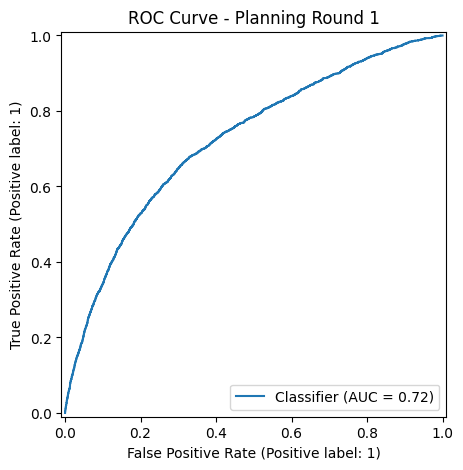

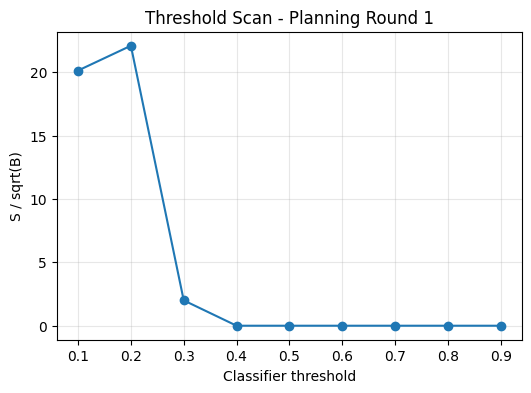


Planning round 2
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `physics_mass_random_forest`: a `random_forest` strategy using 6 features. Rationale: Use invariant masses, angular separations, and b-tag multiplicity because they reflect the four-b signal topology. We will use Random Forest instead of Extra Trees to try to improve upon past attempts and increase best_S_over_sqrt_B.
ClassificationAgent `physics_mass_random_forest` trained `random_forest` using 6 features. Validation AUC = 0.699; test AUC = 0.699. Hyperparameters: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 6, 'max_features': 'sqrt'}.
SignalAnalysisAgent found the best threshold at score >= 0.10, with S/sqrt(B) = 20.51.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_extra_trees,extra_trees,9,"{""max_depth"": 8, ""max_features"": ""sqrt"", ""min_...",0.722801,0.2,22.089532,"Use invariant masses, angular separations, and..."
1,2,physics_mass_random_forest,random_forest,6,"{""max_depth"": 6, ""max_features"": ""sqrt"", ""min_...",0.699303,0.1,20.510290,"Use invariant masses, angular separations, and..."


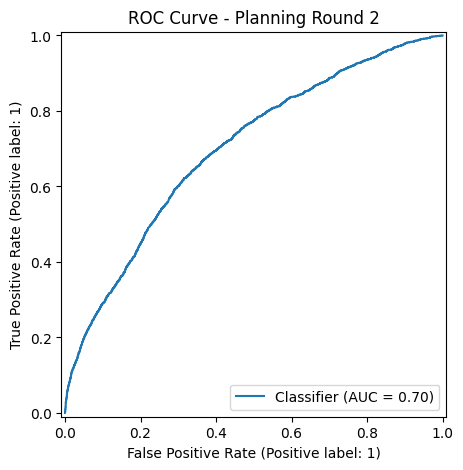

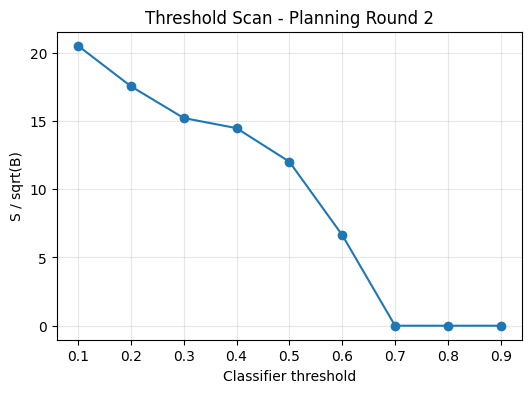

In [21]:
NUM_PLANNING_ROUNDS = 2
history = []
planned_results = []
planning_agent = PlanningAgent()

for round_id in range(1, NUM_PLANNING_ROUNDS + 1):
    print(f"\nPlanning round {round_id}")

    # YOUR CODE HERE: create a FeatureAgent and build X, y from selected_events.
    feature_agent = FeatureAgent()
    X, y = feature_agent.features(selected_events)
    print(feature_agent.describe())

    # YOUR CODE HERE: build dataset_summary for the planning agent.
    # It should include event count, feature count, class counts, and feature names.
    dataset_summary = {
        "n_events": len(X),
        "n_features": X.shape[1],
        "class_counts": {int(k): int(v) for k, v in y.value_counts().sort_index().items()},
        "feature_names": list(X.columns),
    }

    # YOUR CODE HERE: ask the planning agent for the next strategy.
    plan = planning_agent.plan(history=history, dataset_summary=dataset_summary, baseline_summary=baseline_summary)
    print(planning_agent.describe(plan))

    # YOUR CODE HERE: train the ClassificationAgent using the planned strategy.
    classification_agent = ClassificationAgent(strategy=plan)
    classification_agent.train(X, y)
    scores = classification_agent.predict(classification_agent.X_test)
    print(classification_agent.describe())

    # YOUR CODE HERE: run the SignalAnalysisAgent threshold scan.
    signal_agent = SignalAnalysisAgent()
    scan, best = signal_agent.analyze(classification_agent.y_test, scores)
    print(signal_agent.describe())

    # YOUR CODE HERE: save the full round result in planned_results.
    planned_results.append({
        "round": round_id,
        "plan": plan,
        "agent": classification_agent,
        "scan": scan,
        "best": best,
        "scores": scores,
    })

    # YOUR CODE HERE: summarize the round and append it to history.
    round_summary = planning_agent.summarize_round(round_id, plan, classification_agent, best)
    history.append(round_summary)

    if len(planned_results) < round_id:
        raise NotImplementedError("Complete the orchestration TODOs above before plotting round results.")

    # The displays below should work after the variables above are defined.
    display(pd.DataFrame(history))

    RocCurveDisplay.from_predictions(classification_agent.y_test, scores)
    plt.title(f"ROC Curve - Planning Round {round_id}")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(scan["threshold"], scan["S_over_sqrt_B"], marker="o")
    plt.xlabel("Classifier threshold")
    plt.ylabel("S / sqrt(B)")
    plt.title(f"Threshold Scan - Planning Round {round_id}")
    plt.grid(True, alpha=0.3)
    plt.show()

### Final Baseline versus Best Planned Model Comparison

This final comparison selects the planned model with the best threshold-scan value of $S/\sqrt{B}$, then compares it with the baseline random-forest workflow.

Baseline model:
ClassificationAgent `baseline_random_forest` trained `random_forest` using 37 features. Validation AUC = 0.810; test AUC = 0.812. Hyperparameters: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_depth': None, 'max_features': 'sqrt'}.
Baseline best S/sqrt(B) = 39.94 at threshold 0.40.

Best planned model:
ClassificationAgent `physics_mass_gradient_boosting` trained `gradient_boosting` using 24 features. Validation AUC = 0.823; test AUC = 0.822. Hyperparameters: {'max_iter': 300, 'max_depth': 5, 'min_samples_leaf': 20, 'learning_rate': 0.05, 'l2_regularization': 0.1}.
Best planned S/sqrt(B) = 40.59 at threshold 0.60.
Planning rationale: Use invariant masses, angular separations, and b-tag multiplicity because they reflect the four-b signal topology. Gradient boosting may improve performance by reducing overfitting.
Features used (24): ht, m_4j, m_jj_12, deltaR_jj_12, min_deltaR_jj, n_btags, m_jj_13, deltaR_jj_13, m_jj_14, deltaR_jj_14, m_jj_23, deltaR_jj_23, m_jj_24, de

,model,strategy,model_family,features_used,test_auc,best_threshold,best_S_over_sqrt_B
0,baseline,baseline_random_forest,random_forest,37,0.811746,0.4,39.939491
1,best_planned,physics_mass_gradient_boosting,gradient_boosting,24,0.821661,0.6,40.585726


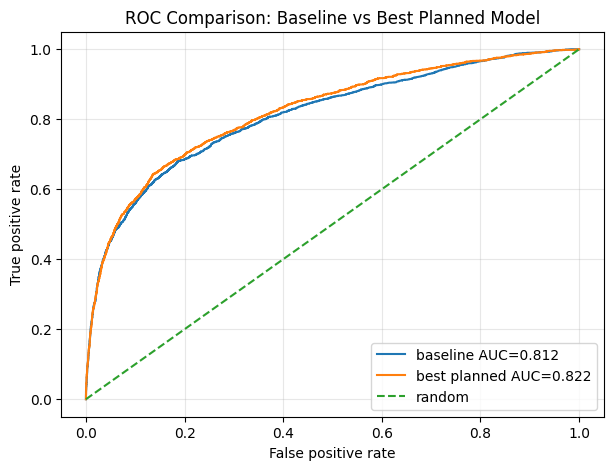

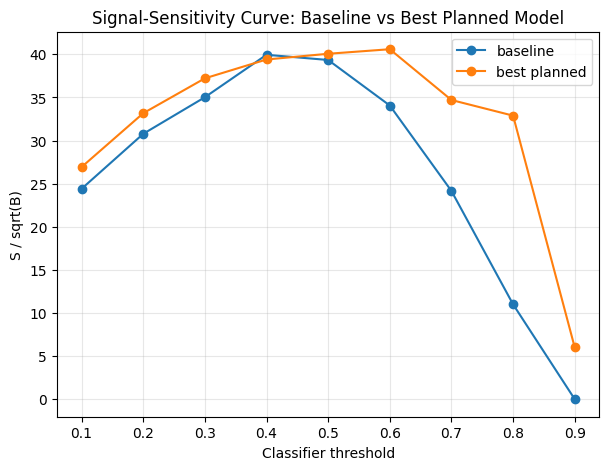

In [16]:
if not planned_results:
    raise RuntimeError("Run the Agentic Planning Loop before running this final comparison cell.")

best_result = max(planned_results, key=lambda result: result["best"]["S_over_sqrt_B"])
best_agent = best_result["agent"]
best_plan = best_result["plan"]
best_scan = best_result["scan"]
best_scores = best_result["scores"]

print("Baseline model:")
print(baseline_classifier.describe())
print(f"Baseline best S/sqrt(B) = {baseline_best['S_over_sqrt_B']:.2f} at threshold {baseline_best['threshold']:.2f}.")
print()

print("Best planned model:")
print(best_agent.describe())
print(
    f"Best planned S/sqrt(B) = {best_result['best']['S_over_sqrt_B']:.2f} "
    f"at threshold {best_result['best']['threshold']:.2f}."
)
print(f"Planning rationale: {best_plan['rationale']}")
print(f"Features used ({len(best_plan['feature_columns'])}): {', '.join(best_plan['feature_columns'])}")
print(f"Hyperparameters: {json.dumps(best_plan['hyperparameters'], sort_keys=True)}")

comparison = pd.DataFrame([
    {
        "model": "baseline",
        "strategy": baseline_classifier.name,
        "model_family": baseline_classifier.strategy["model_family"],
        "features_used": len(baseline_classifier.feature_names_),
        "test_auc": baseline_classifier.metrics["test"]["auc"],
        "best_threshold": baseline_best["threshold"],
        "best_S_over_sqrt_B": baseline_best["S_over_sqrt_B"],
    },
    {
        "model": "best_planned",
        "strategy": best_plan["strategy_name"],
        "model_family": best_plan["model_family"],
        "features_used": len(best_plan["feature_columns"]),
        "test_auc": best_agent.metrics["test"]["auc"],
        "best_threshold": best_result["best"]["threshold"],
        "best_S_over_sqrt_B": best_result["best"]["S_over_sqrt_B"],
    },
])
display(comparison)

baseline_fpr, baseline_tpr, _ = roc_curve(baseline_classifier.y_test, baseline_scores)
best_fpr, best_tpr, _ = roc_curve(best_agent.y_test, best_scores)

plt.figure(figsize=(7, 5))
plt.plot(baseline_fpr, baseline_tpr, label=f"baseline AUC={baseline_classifier.metrics['test']['auc']:.3f}")
plt.plot(best_fpr, best_tpr, label=f"best planned AUC={best_agent.metrics['test']['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Comparison: Baseline vs Best Planned Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(baseline_scan["threshold"], baseline_scan["S_over_sqrt_B"], marker="o", label="baseline")
plt.plot(best_scan["threshold"], best_scan["S_over_sqrt_B"], marker="o", label="best planned")
plt.xlabel("Classifier threshold")
plt.ylabel("S / sqrt(B)")
plt.title("Signal-Sensitivity Curve: Baseline vs Best Planned Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
